In [1]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import wandb
import xarray as xr
from context_flux_no.training.io import load_model
from jaxtyping import Array, Float
from matplotlib.animation import ArtistAnimation


datadir = Path("../../data")
checkpoint_dir = Path("../../checkpoints")

jax.config.update("jax_default_device", jax.devices("gpu")[2])

E0317 16:13:21.840922 2344146 platform_util.cc:250] Failed to create stream executor for device CUDA:5: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0317 16:13:21.841027 2344146 platform_util.cc:250] Failed to create stream executor for device CUDA:6: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0317 16:13:21.968664 2344146 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.10.2 but source was compiled with: 9.12.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0317 16:13:21.997104 2344146 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.10.2 but source was compiled with: 9.12.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the l

## Query wandb API and obtain loss curves

In [169]:
api = wandb.Api()
run_dpot = api.run("jhko725/hyperfluxfno/cgwa58nd")
run_hyperfluxfno = api.run("jhko725/hyperfluxfno/nni87so3")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jhko725/.netrc.


<IPython.core.display.Javascript object>

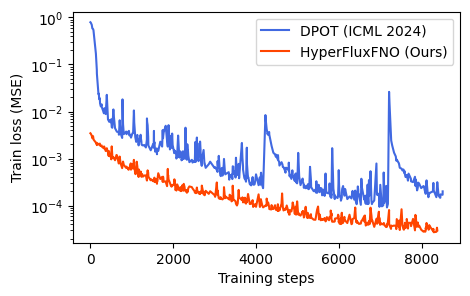

In [184]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(
    *run_dpot.history(keys=["train_loss"]).to_numpy().T,
    label="DPOT (ICML 2024)",
    color="royalblue",
)
ax.plot(
    *run_hyperfluxfno.history(keys=["train_loss"]).to_numpy().T,
    label="HyperFluxFNO (Ours)",
    color="orangered",
)
ax.set_yscale("log", base=10)
ax.set_ylabel("Train loss (MSE)")
ax.set_xlabel("Training steps")
ax.legend()
fig

## Load trained models and dataset

In [2]:
CHECKPOINT_DICT = {
    "DPOT": {
        "DenoisingOneStepLoss": "26-03-13-20:29:40",
        "OneStepLoss": "26-03-13-13:54:10",
        "PushforwardOneStepLoss": "26-03-12-18:22:52",
    },
    "HyperFluxFNO": {
        "DenoisingOneStepLoss": "26-03-13-13:54:10",
        "OneStepLoss": "26-03-13-13:54:06",
        "PushforwardOneStepLoss": "26-03-12-18:11:39",
    },
    "HyperFluxFNOLocal": {
        "DenoisingOneStepLoss": "26-03-13-23:33:23",
        "OneStepLoss": "26-03-12-17:10:10",
        "PushforwardOneStepLoss": "26-03-13-21:14:30",
    },
}

## Compare model performance for different training methods

In [3]:
dataset_train = xr.open_dataset(
    datadir / "cubic_no_source_large_train.hdf5", engine="h5netcdf", chunks={}
)
dataset_train_extrap = dataset_train.isel({"t": slice(61, None)})

batch_extrap = dataset_train_extrap["values"].isel({"ic": 0}).compute().to_numpy()

### DPOT

In [ ]:
from tqdm import tqdm


u_pred_dict = dict()

for method, ckpt_name in tqdm(CHECKPOINT_DICT["DPOT"].items()):
    model = load_model(checkpoint_dir / "DPOT" / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=None, num_steps=20)
    )(batch_extrap[:, :20])[0]

  0%|          | 0/3 [00:00<?, ?it/s]E0317 16:21:56.076974 2344146 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.10.2 but source was compiled with: 9.12.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0317 16:21:56.088157 2344146 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.10.2 but source was compiled with: 9.12.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
  0%|          | 0/3 [00:01<?, ?it/s]


InstantiationException: Error in call to target 'jax._src.random.key':
JaxRuntimeError('FAILED_PRECONDITION: DNN library initialization failed. Look at the errors above for more details.')
full_key: key

In [14]:
dpot = load_model(
    checkpoint_dir / "DPOT/OneStepLoss/26-03-13-13:54:10", step_number=45887
)
hyperfluxfno = load_model(checkpoint_dir / "HyperFluxFNO/26-03-12-18:11:39")
# hyperfluxfno_local = load_model(checkpoint_dir / "HyperFluxFNOLocal/26-03-12-17:10:10")
hyperfluxfno_local = load_model(
    checkpoint_dir / "HyperFluxFNO/OneStepLoss/26-03-13-13:54:06", step_number=31765
)

In [5]:
batch_extrap[:, 20:].shape

(1000, 20, 1, 100)

## Generate model predictions and visualize

In [5]:
dpot = eqx.nn.inference_mode(dpot, True)
batch_extrap_pred_dpot = eqx.filter_vmap(
    lambda u: dpot.rollout(u, args=None, num_steps=20)
)(batch_extrap[:, :20])[0]

W0313 20:00:43.598042  384583 bfc_allocator.cc:502] Allocator (GPU_3_bfc) ran out of memory trying to allocate 32.75GiB (rounded to 35169370624)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0313 20:00:43.802491  384583 bfc_allocator.cc:513] **__________________________________________________________________________________________________


In [6]:
dt = float(dataset_train_extrap["t"][1] - dataset_train_extrap["t"][0])
dx = float(dataset_train_extrap["x"][1] - dataset_train_extrap["x"][0])

hyperfluxfno = eqx.nn.inference_mode(hyperfluxfno, True)
batch_extrap_pred_hyperfluxfno = eqx.filter_vmap(
    lambda u: hyperfluxfno.rollout(
        u, args=(dt, dx), num_steps=20, key=jax.random.key(0)
    )
)(batch_extrap[:, :20])[0]

E0313 20:00:49.797821  384583 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0313 20:00:51.232278  384583 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


In [15]:
hyperfluxfno_local = eqx.nn.inference_mode(hyperfluxfno_local, True)
batch_extrap_pred_hyperfluxfnolocal = eqx.filter_vmap(
    lambda u: hyperfluxfno_local.rollout(
        u, args=(dt, dx), num_steps=20, key=jax.random.key(0)
    )
)(batch_extrap[:, :20])[0]

In [16]:
batch_extrap_pred_hyperfluxfnolocal[0].shape

(20, 1, 100)

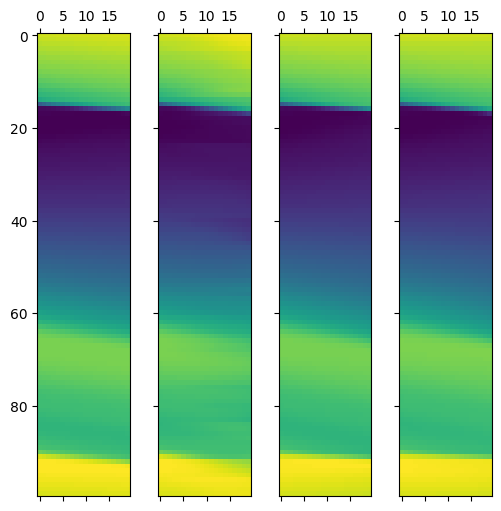

In [17]:
sample_idx = 80
fig, axes = plt.subplots(
    1, 4, figsize=(5, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[1].matshow(batch_extrap_pred_dpot[sample_idx, :, 0].T)
axes[2].matshow(batch_extrap_pred_hyperfluxfno[sample_idx, :, 0].T)
axes[3].matshow(batch_extrap_pred_hyperfluxfnolocal[sample_idx, :, 0].T)


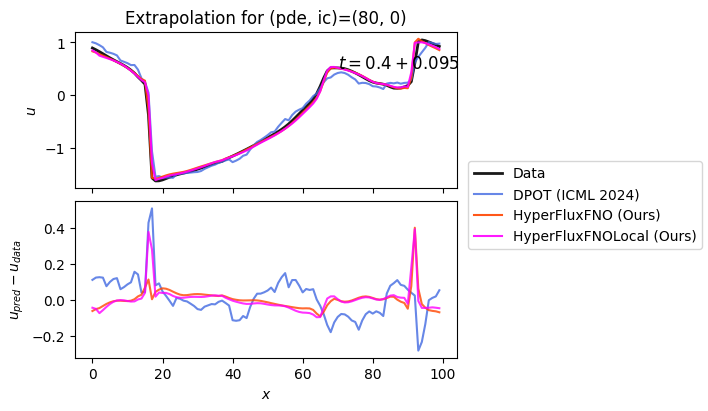

In [18]:
plt.rcParams["animation.html"] = "jshtml"
fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True, constrained_layout=True)


def make_frame(timestep: int):
    if timestep == 0:
        plot_kwargs = {"animated": False}
        axes[-1].set_xlabel("$x$")
        axes[0].set_ylabel("$u$")
        axes[1].set_ylabel("$u_{pred}-u_{data}$")
    else:
        plot_kwargs = {"animated": True}

    plot1 = axes[0].plot(
        batch_extrap[sample_idx, 20 + timestep, 0].T,
        label="Data",
        linewidth=2.0,
        color="black",
        alpha=0.9,
        **plot_kwargs,
    )[0]
    plot2 = axes[0].plot(
        batch_extrap_pred_dpot[sample_idx, timestep, 0].T,
        label="DPOT (ICML 2024)",
        alpha=0.8,
        linewidth=1.5,
        color="royalblue",
        **plot_kwargs,
    )[0]
    plot3 = axes[0].plot(
        batch_extrap_pred_hyperfluxfno[sample_idx, timestep, 0].T,
        label="HyperFluxFNO (Ours)",
        alpha=0.9,
        linewidth=1.5,
        color="orangered",
        **plot_kwargs,
    )[0]
    plot4 = axes[0].plot(
        batch_extrap_pred_hyperfluxfnolocal[sample_idx, timestep, 0].T,
        label="HyperFluxFNOLocal (Ours)",
        alpha=0.9,
        linewidth=1.5,
        color="magenta",
        **plot_kwargs,
    )[0]
    plot5 = axes[1].plot(
        batch_extrap_pred_dpot[sample_idx, timestep, 0].T
        - batch_extrap[sample_idx, 20 + timestep, 0].T,
        label="DPOT (ICML 2024)",
        alpha=0.8,
        linewidth=1.5,
        color="royalblue",
        **plot_kwargs,
    )[0]
    plot6 = axes[1].plot(
        batch_extrap_pred_hyperfluxfno[sample_idx, timestep, 0].T
        - batch_extrap[sample_idx, 20 + timestep, 0].T,
        label="HyperFluxFNO (Ours)",
        alpha=0.8,
        linewidth=1.5,
        color="orangered",
        **plot_kwargs,
    )[0]
    plot7 = axes[1].plot(
        batch_extrap_pred_hyperfluxfnolocal[sample_idx, timestep, 0].T
        - batch_extrap[sample_idx, 20 + timestep, 0].T,
        label="HyperFluxFNOLocal (Ours)",
        alpha=0.8,
        linewidth=1.5,
        color="magenta",
        **plot_kwargs,
    )[0]
    text_y = (
        jnp.max(batch_extrap[sample_idx, :, 0]) * 0.8
        + jnp.min(batch_extrap[sample_idx, :, 0]) * 0.2
    )
    text0 = axes[0].text(70, text_y, f"$t=0.4+{dt * timestep:.3f}$", fontsize="large")
    if timestep == 0:
        fig.legend(*axes[0].get_legend_handles_labels(), loc="outside center right")
    axes[0].set_title(f"Extrapolation for (pde, ic)={(sample_idx, 0)}")
    return (plot1, plot2, plot3, plot4, plot5, plot6, plot7, text0)


frames = [make_frame(i) for i in range(20)]


ani = ArtistAnimation(fig, frames, interval=50, blit=True)
# ani.save(f"../../figures/cubic_extrapolation_{sample_idx}_0.gif")
ani

## Compute rel. RMSE as a function of rollout

In [19]:
def relative_rmse(
    u_pred: Float[Array, "channels ..."], u_data: Float[Array, "channels ..."]
):
    return jnp.sqrt(jnp.mean((u_pred - u_data) ** 2)) / jnp.sqrt(jnp.mean(u_data**2))

In [20]:
rel_rmse_dpot = jnp.mean(
    jax.vmap(jax.vmap(relative_rmse))(batch_extrap[:, 20:], batch_extrap_pred_dpot),
    axis=0,
)
rel_rmse_hyperfluxfno = jnp.mean(
    jax.vmap(jax.vmap(relative_rmse))(
        batch_extrap[:, 20:], batch_extrap_pred_hyperfluxfno
    ),
    axis=0,
)
rel_rmse_hyperfluxfnolocal = jnp.mean(
    jax.vmap(jax.vmap(relative_rmse))(
        batch_extrap[:, 20:], batch_extrap_pred_hyperfluxfnolocal
    ),
    axis=0,
)

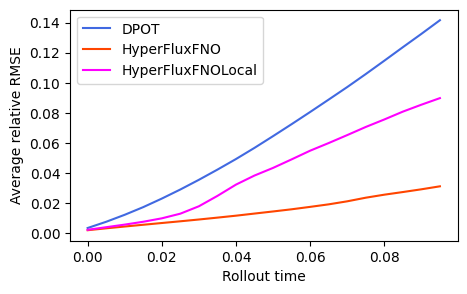

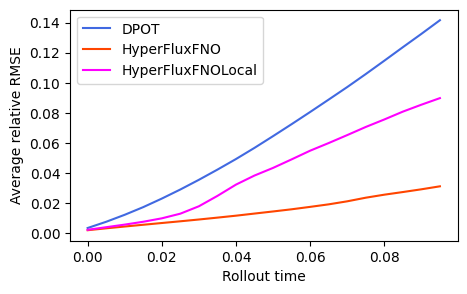

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(
    jnp.arange(len(rel_rmse_dpot)) * dt, rel_rmse_dpot, label="DPOT", color="royalblue"
)
ax.plot(
    jnp.arange(len(rel_rmse_hyperfluxfno)) * dt,
    rel_rmse_hyperfluxfno,
    label="HyperFluxFNO",
    color="orangered",
)
ax.plot(
    jnp.arange(len(rel_rmse_hyperfluxfnolocal)) * dt,
    rel_rmse_hyperfluxfnolocal,
    label="HyperFluxFNOLocal",
    color="magenta",
)
ax.set_ylabel("Average relative RMSE")
ax.set_xlabel("Rollout time")
ax.legend()
fig